#  Feature Engineering

In this section, new variables are created from the existing dataset in order to improve data interpretability and enhance potential model performance.

Although the dataset is already well-structured, feature engineering helps to:
- Capture hidden patterns in customer behavior
- Aggregate related variables into meaningful metrics


The goal is not to increase complexity, but to create more informative representations of the data that better reflect customer usage behavior and engagement.

In [11]:
import pandas as pd 
import matplotlib.pyplot as plt
import sys
sys.path.append("..")
from cleaning import clean
df=pd.read_csv('../data/Telco-Customer-Churn.csv')
df = clean(df)

## Total Services

In [ ]:
# creating total services column
service_cols = [
    "PhoneService", 
    "MultipleLines", 
    "InternetService",
    "OnlineSecurity", 
    "OnlineBackup", 
    "DeviceProtection",
    "TechSupport", 
    "StreamingTV", 
    "StreamingMovies"
    ]
df["TotalServices"] = df[service_cols].apply(lambda x: (x == "Yes").sum(), axis=1)

In [13]:
df["TotalServices"].describe()

count    7032.000000
mean        3.363339
std         2.062067
min         0.000000
25%         1.000000
50%         3.000000
75%         5.000000
max         8.000000
Name: TotalServices, dtype: float64

### Insight 

The new feature **TotalServices** was created to measure how many services each customer uses across the platform (e.g., phone, internet add-ons, streaming, and support services).

The distribution shows that:
- The average customer uses approximately **3.36 services**
- Most customers fall between **1 and 5 services**
- Very few customers use the maximum number of available services

### Interpretation:

This suggests that customer engagement with additional services is moderate. Most users are not fully utilizing the full product ecosystem, which may indicate an opportunity for cross-selling or service bundling strategies.

### Business implication:
Customers with higher service usage may exhibit different churn behavior compared to low-engagement users, which will be explored in the next analysis steps.

## Tenure Group
In this step, we will transform the continuous variable **tenure** into categorical groups representing customer lifecycle stages.

Instead of using raw numerical values, we will segment customers based on how long they have been with the company:

- 0–1 year (new customers)
- 1–2 years (early-stage customers)
- 2–4 years (established customers)
- 4+ years (long-term customers)

In [14]:
df["TenureGroup"] = pd.cut(
    df["tenure"],
    bins=[0, 12, 24, 48, 72],
    labels=["0-1 year", "1-2 years", "2-4 years", "4+ years"]
)

In [15]:
df["TenureGroup"].value_counts()

TenureGroup
4+ years     2239
0-1 year     2175
2-4 years    1594
1-2 years    1024
Name: count, dtype: int64

### Insight
The company has two strong customer base groups:

-many new customers (0-1 year)

-many very old customers (4+ years)

-but a "hole" in the middle (1-2 years)

In [16]:
#CHURN PER TENURE GROUP
df.groupby("TenureGroup")["Churn"].mean().sort_values(ascending=False) * 100

TenureGroup
0-1 year     47.678161
1-2 years    28.710938
2-4 years    20.388959
4+ years      9.513176
Name: Churn, dtype: float64

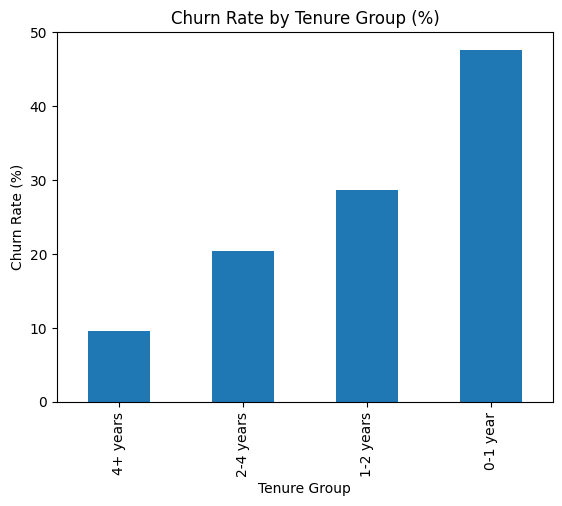

In [17]:
tenure_churn = df.groupby("TenureGroup")["Churn"].mean().sort_values() * 100

tenure_churn.plot(kind="bar")

plt.title("Churn Rate by Tenure Group (%)")
plt.xlabel("Tenure Group")
plt.ylabel("Churn Rate (%)")

plt.show()

### Insight
Customers in their first year present a significantly higher churn rate (47.7%), which decreases steadily as tenure increases. Customers with more than 4 years of tenure show strong retention (only 9.5% churn).

This indicates that churn is primarily an early-stage customer problem, suggesting that retention strategies should focus on the first year of the customer lifecycle.